In [ ]:
# Customer Churn Prediction

## Project Overview
Customer Churn Prediction is a Machine Learning project that predicts whether a customer is likely to stop using a company's service. Customer retention is important for business growth, and this project helps identify customers who may leave so that appropriate actions can be taken.

## Objective
To build a classification model that predicts customer churn using customer demographic information, subscription details, and service usage patterns.

## Dataset Features
The dataset contains customer-related information such as:

- Customer ID
- Age
- Gender
- Tenure
- Usage Frequency
- Support Calls
- Payment Delay
- Subscription Type
- Contract Length
- Total Spend
- Last Interaction
- Churn (Target Variable)

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Joblib

## Project Workflow

### 1. Data Collection
Loaded the customer churn dataset using Pandas.

### 2. Data Preprocessing
- Removed missing values
- Encoded categorical features
- Prepared data for machine learning

### 3. Exploratory Data Analysis (EDA)
- Churn distribution analysis
- Correlation heatmap
- Feature relationship analysis

### 4. Feature Engineering
- Selected relevant features
- Split data into training and testing sets
- Applied feature scaling using StandardScaler

### 5. Model Building
Implemented Logistic Regression for customer churn prediction.

### 6. Model Evaluation
Evaluated model performance using:
- Accuracy Score
- Classification Report
- Confusion Matrix

### 7. Model Saving
Saved the trained model using Joblib for future predictions.

## Results
The Logistic Regression model successfully predicted customer churn with good accuracy and provided valuable insights into customer behavior.

## Skills Learned
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Classification Algorithms
- Model Evaluation
- Data Visualization
- Machine Learning Workflow

## Conclusion
This project demonstrates how machine learning can be used to identify customers who are likely to leave a service. Such predictions help organizations improve customer retention strategies and reduce revenue loss.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("customer_churn_data.csv")
print(df.head())

   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                18      0  
4                18      0  


In [4]:
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB
None
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type

In [8]:
df.dropna(inplace=True)

In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

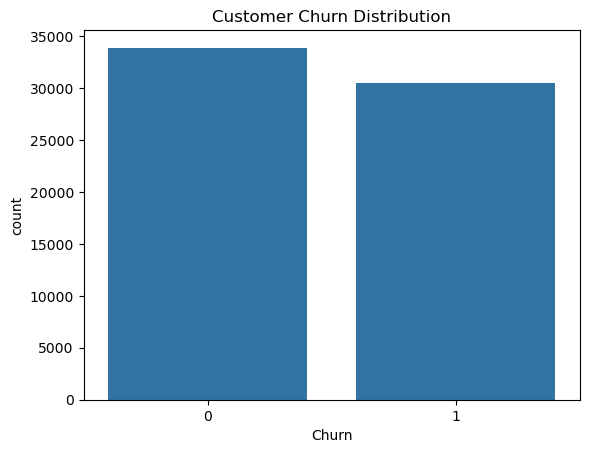

In [10]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

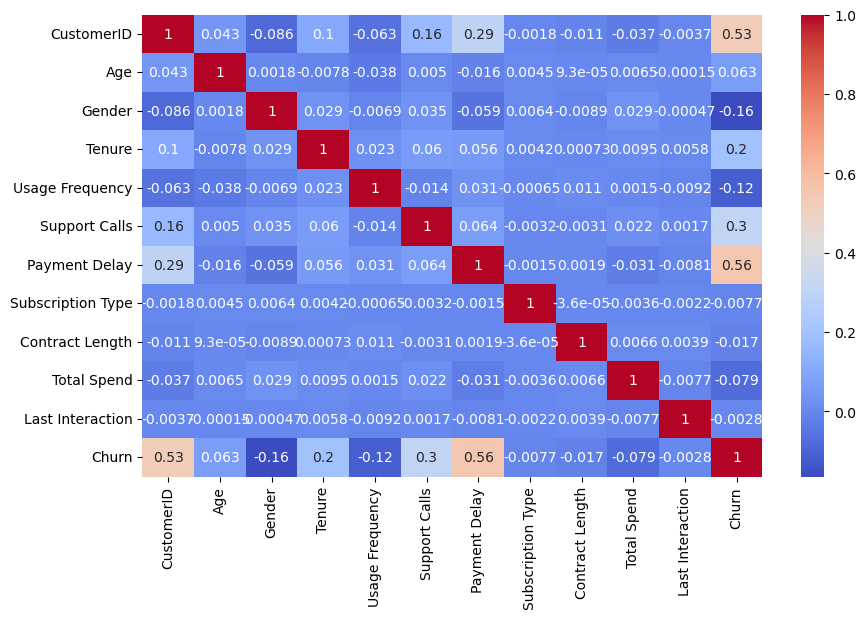

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [48]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

print("Model Training Successful")

Model Training Successful


In [60]:
y_pred = model.predict(X_test)

In [61]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8653980582524272


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      6793
           1       0.86      0.86      0.86      6082

    accuracy                           0.87     12875
   macro avg       0.86      0.86      0.86     12875
weighted avg       0.87      0.87      0.87     12875



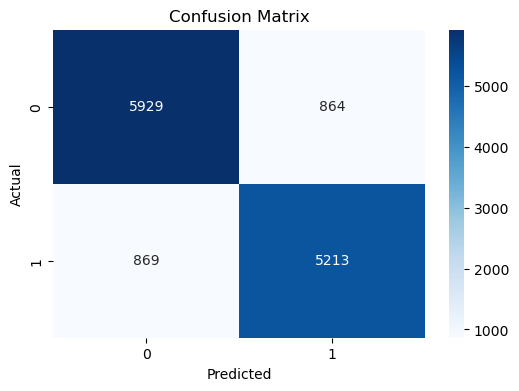

In [63]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [64]:
import joblib

joblib.dump(model, "customer_churn_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [65]:
print("Customer Churn Prediction Project Completed Successfully!")
print("Final Accuracy:", accuracy)

Customer Churn Prediction Project Completed Successfully!
Final Accuracy: 0.8653980582524272
